# Diseño de Sistema de Generación Fotovoltaica Off-Grid

---

| | |
|---|---|
| **Proyecto** | Sistema off-grid — consumo hogareño |
| **Modo** | Autónomo (sin conexión a red) |
| **Ubicación** | *(editar en Sección 1 — parámetros)* |
| **Fecha del informe** | 2026 |

---


## 0. Entorno — Instalación de dependencias

Ejecutar esta celda la primera vez.

In [19]:
import subprocess, sys

def instalar(paquete):
    subprocess.check_call([sys.executable, "-m", "pip", "install", paquete, "-q"])

for pkg in ["pvlib", "pandas", "numpy", "matplotlib", "requests", "tabulate", "folium"]:
    try:
        __import__(pkg)
    except ImportError:
        print(f"Instalando {pkg}...")
        instalar(pkg)

print("✓ Todas las dependencias disponibles")

✓ Todas las dependencias disponibles


In [20]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import Markdown, display
import warnings
warnings.filterwarnings('ignore')

import pvlib
from pvlib import location, irradiance

import folium

%matplotlib inline
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'text.color': '#1f2937',
    'axes.labelcolor': '#1f2937',
    'xtick.color': '#1f2937',
    'ytick.color': '#1f2937',
    'figure.dpi': 120,
    'figure.figsize': (11, 4),
    'axes.grid': True,
    'grid.alpha': 0.25,
})

print(f"pvlib  : {pvlib.__version__}")
print(f"pandas : {pd.__version__}")
print("✓ Entorno listo")

pvlib  : 0.15.2
pandas : 3.0.5
✓ Entorno listo


## 1. Datos del proyecto
### ⚙️ PARÁMETROS EDITABLES — Modificar acá para recalcular todo el informe

In [21]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         PARÁMETROS EDITABLES DEL PROYECTO                    ║
# ╚══════════════════════════════════════════════════════════════╝

# ── Datos del sitio ── EDITAR con la ubicación real del proyecto ────
LATITUD      = -40.72247656579989     # grados decimales (Sur = negativo) -40.722476565799894, -66.22894159686423
LONGITUD     = -66.22894159686423     # grados decimales (Oeste = negativo)
ALTITUD      = 25            # metros sobre el nivel del mar
ZONA_HORARIA = 'America/Buenos_Aires'
NOMBRE_SITIO = 'Vivienda — off-grid'   # EDITAR

# ── Geometría del arreglo ────────────────────────────────────────────
INCLINACION_GRADOS = 30     # ángulo de inclinación del panel [tilt, β]
ACIMUT_GRADOS       = 15     # grados desde Norte (0=N, 90=E, -90=O) — EDITAR según consigna

# ── Sistema off-grid: tensión y autonomía ────────────────────────────
V_SISTEMA        = 48        # V — tensión de bus DC (paneles/controlador/baterías/inversor)
DIAS_AUTONOMIA   = 2         # días sin sol que el banco debe cubrir solo
DOD              = 0.50      # profundidad de descarga — plomo-ácido GEL/AGM
ETA_BATERIA      = 0.88      # rendimiento de ciclo carga/descarga — plomo-ácido

# ── Parámetros del panel FV (datasheet) ──────────────────────────────
PANEL = {
    'modelo'     : 'Panel monocristalino 450W',
    'Wp'         : 450,
    'Voc_stc'    : 41.8,     # V
    'Vmpp_stc'   : 34.9,     # V
    'Isc_stc'    : 13.9,     # A
    'Impp_stc'   : 12.9,     # A
    'beta_oc'    : -0.270,   # %/°C — coef. temp. de Voc
    'alpha_isc'  : 0.045,    # %/°C — coef. temp. de Isc
    'gamma_pmpp' : -0.350,   # %/°C — coef. temp. de Pmpp
    'NOCT'       : 44,       # °C
    'largo_mm'   : 2094,
    'ancho_mm'   : 1038,
}

# ── Parámetros del controlador de carga MPPT (datasheet) ─────────────
CONTROLADOR = {
    'modelo'      : 'MPPT 150/70',
    'V_pv_max'    : 150,   # V — tensión máxima admisible en la entrada FV
    'I_bat_max'   : 70,    # A — corriente máxima de carga hacia batería
    'I_pv_max'    : 70,    # A — corriente máxima de entrada FV (cortocircuito)
    'eta'         : 0.97,  # eficiencia de conversión
    'V_bat_nom'   : V_SISTEMA,
}

# ── Parámetros del inversor off-grid (datasheet) ──────────────────────
INVERSOR = {
    'modelo'        : 'Inversor/cargador off-grid senoidal puro',
    'P_ac_nom_w'    : 3000,   # W — potencia nominal continua
    'P_ac_surge_w'  : 6000,   # W — potencia pico/surge (arranque de motores, ~2x nominal)
    'V_dc_nom'      : V_SISTEMA,
    'eta'           : 0.93,   # eficiencia de conversión DC/AC
    'V_ac'          : 220,
    'fases'         : 1,
}

# ── Parámetros de la batería individual (datasheet) ───────────────────
BATERIA = {
    'modelo'   : 'Batería GEL 12V 200Ah',
    'V_nom'    : 12,     # V por unidad
    'Ah'       : 200,    # Ah por unidad
}

# ── Condiciones extremas de temperatura ───────────────────────────────
T_CEL_MIN = -5.0
T_CEL_MAX = 71.0

# ── Pérdidas del sistema (más allá del PR de irradiancia) ────────────
PR = 0.78   # Performance Ratio del generador FV (temp, suciedad, cableado DC, mismatch)

parametros_md = f"""
---
### 📋 Resumen de Parámetros del Proyecto
---

| 🌍 Ubicación | Detalle |
| :--- | :--- |
| **Sitio** | {NOMBRE_SITIO} |
| **Coordenadas** | {LATITUD}, {LONGITUD} (Altitud: {ALTITUD}m) |
| **Modo** | Off-grid (autónomo) |

<br>

| ⚙️ Equipamiento Seleccionado | Especificaciones |
| :--- | :--- |
| **Panel Solar** | {PANEL['modelo']} — **{PANEL['Wp']} Wp** |
| **Controlador de carga** | {CONTROLADOR['modelo']} (MPPT) |
| **Inversor** | {INVERSOR['modelo']} — **{INVERSOR['P_ac_nom_w']/1000:.1f} kW** nominal |
| **Batería** | {BATERIA['modelo']} |
| **Tensión de sistema** | {V_SISTEMA} V |

<br>

| 📐 Geometría del Arreglo | Medida |
| :--- | :--- |
| **Inclinación (Tilt)** | {INCLINACION_GRADOS}° |
| **Acimut** | {ACIMUT_GRADOS}° |

<br>

| 🔋 Parámetros de Autonomía | Valor |
| :--- | :--- |
| **Días de autonomía** | {DIAS_AUTONOMIA} |
| **Profundidad de descarga (DoD)** | {DOD*100:.0f}% |
| **Rendimiento de batería** | {ETA_BATERIA*100:.0f}% |
---
"""
display(Markdown(parametros_md))


---
### 📋 Resumen de Parámetros del Proyecto
---

| 🌍 Ubicación | Detalle |
| :--- | :--- |
| **Sitio** | Vivienda — off-grid |
| **Coordenadas** | -40.72247656579989, -66.22894159686423 (Altitud: 25m) |
| **Modo** | Off-grid (autónomo) |

<br>

| ⚙️ Equipamiento Seleccionado | Especificaciones |
| :--- | :--- |
| **Panel Solar** | Panel monocristalino 450W — **450 Wp** |
| **Controlador de carga** | MPPT 150/70 (MPPT) |
| **Inversor** | Inversor/cargador off-grid senoidal puro — **3.0 kW** nominal |
| **Batería** | Batería GEL 12V 200Ah |
| **Tensión de sistema** | 48 V |

<br>

| 📐 Geometría del Arreglo | Medida |
| :--- | :--- |
| **Inclinación (Tilt)** | 30° |
| **Acimut** | 15° |

<br>

| 🔋 Parámetros de Autonomía | Valor |
| :--- | :--- |
| **Días de autonomía** | 2 |
| **Profundidad de descarga (DoD)** | 50% |
| **Rendimiento de batería** | 88% |
---


### 1.1 Ubicación en el mapa

Verificar visualmente que las coordenadas caen sobre el sitio real (útil para chequear sombras de edificios/árboles vecinos, orientación del techo, etc.).

In [22]:
mapa = folium.Map(location=[LATITUD, LONGITUD], zoom_start=17, tiles='OpenStreetMap')
folium.Marker(
    [LATITUD, LONGITUD],
    popup=f"{NOMBRE_SITIO}<br>{LATITUD}, {LONGITUD}",
    tooltip=NOMBRE_SITIO,
    icon=folium.Icon(color='orange', icon='bolt', prefix='fa'),
).add_to(mapa)
mapa

## 2. Consumo del hogar — planilla de cargas

Completar con los artefactos reales del proyecto.

In [23]:
cargas = pd.DataFrame([
    {"Artefacto": "Heladera",             "Potencia_W": 150, "Horas_dia": 8,   "Tipo": "AC", "Cantidad": 1},
    {"Artefacto": "Iluminación LED",      "Potencia_W": 8,   "Horas_dia": 5,   "Tipo": "AC", "Cantidad": 8},
    {"Artefacto": "TV",                   "Potencia_W": 80,  "Horas_dia": 3,   "Tipo": "AC", "Cantidad": 1},
    {"Artefacto": "Router / módem",       "Potencia_W": 10,  "Horas_dia": 24,  "Tipo": "AC", "Cantidad": 1},
    {"Artefacto": "Carga de celulares",   "Potencia_W": 15,  "Horas_dia": 3,   "Tipo": "DC", "Cantidad": 1},
    {"Artefacto": "Bomba de agua",        "Potencia_W": 400, "Horas_dia": 0.5, "Tipo": "AC", "Cantidad": 1},
])
cargas["Wh_dia"] = cargas["Potencia_W"] * cargas["Horas_dia"] * cargas["Cantidad"]

Ed              = cargas["Wh_dia"].sum()                                  # Wh/día
Pico_simultaneo = (cargas["Potencia_W"] * cargas["Cantidad"]).sum()       # W

display(cargas)
print(f"\nConsumo diario total Ed         : {Ed:.0f} Wh/día  ({Ed/1000:.2f} kWh/día)")
print(f"Potencia simultánea máxima (ref): {Pico_simultaneo:.0f} W")

,Artefacto,Potencia_W,Horas_dia,Tipo,Cantidad,Wh_dia
0,Heladera,150,8.0,AC,1,1200.0
1,Iluminación LED,8,5.0,AC,8,320.0
2,TV,80,3.0,AC,1,240.0
3,Router / módem,10,24.0,AC,1,240.0
4,Carga de celulares,15,3.0,DC,1,45.0
5,Bomba de agua,400,0.5,AC,1,200.0



Consumo diario total Ed         : 2245 Wh/día  (2.25 kWh/día)
Potencia simultánea máxima (ref): 719 W


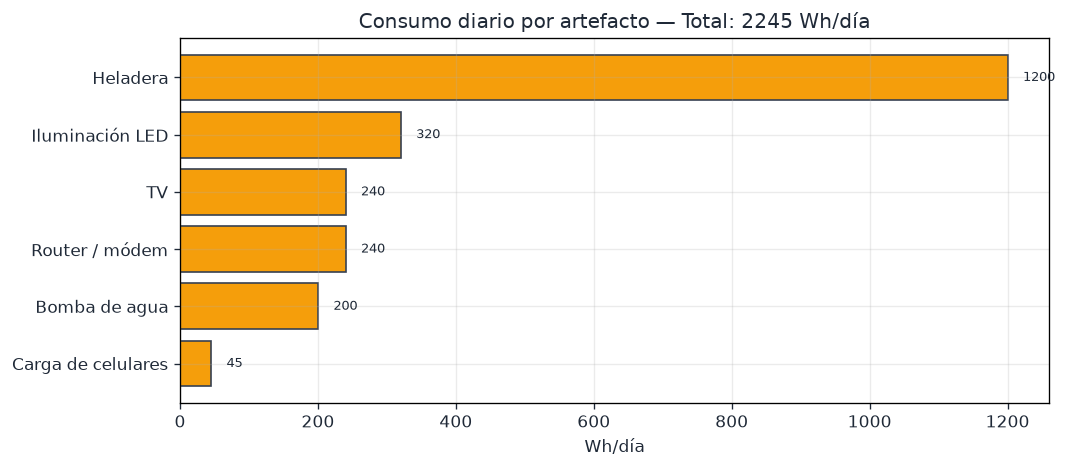

In [24]:
fig, ax = plt.subplots(figsize=(9,4))
orden = cargas.sort_values("Wh_dia", ascending=True)
ax.barh(orden["Artefacto"], orden["Wh_dia"], color='#f59e0b', edgecolor='#374151')
ax.set_xlabel('Wh/día')
ax.set_title(f'Consumo diario por artefacto — Total: {Ed:.0f} Wh/día')
for i, (v, art) in enumerate(zip(orden["Wh_dia"], orden["Artefacto"])):
    ax.text(v + Ed*0.01, i, f'{v:.0f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

## 3. Recurso solar del sitio

### 3.1 Posición geográfica y descarga de datos TMY desde PVGIS

In [ ]:
from pvlib.iotools import get_pvgis_tmy

sitio = location.Location(
    latitude=LATITUD, longitude=LONGITUD, altitude=ALTITUD,
    tz=ZONA_HORARIA, name=NOMBRE_SITIO,
)
print(f"Sitio definido: {sitio.name}")
print(f"  Lat: {sitio.latitude}° | Lon: {sitio.longitude}° | Alt: {sitio.altitude} m")
print()
print("Descargando TMY desde PVGIS...")

try:
    tmy_data, metadata = get_pvgis_tmy(
        latitude=LATITUD, longitude=LONGITUD,
        usehorizon=True, startyear=2005, endyear=2020,
        map_variables=True,
    )
    print(f"✓ TMY descargado: {len(tmy_data)} registros horarios (8760 h/año)")
except Exception as e:
    print(f"⚠ No se pudo descargar el TMY online: {e}")
    print("  Usando datos manuales de respaldo...")
    tmy_data = None

Sitio definido: Vivienda — off-grid
  Lat: -40.72247656579989° | Lon: -66.22894159686423° | Alt: 25 m

Descargando TMY desde PVGIS...


### 3.2 Irradiancia sobre el plano del array (POA)

In [ ]:
times = pd.date_range(start='2023-01-01', periods=8760, freq='h', tz=ZONA_HORARIA)

if tmy_data is not None:
    tmy_data.index = times
    solar_pos = sitio.get_solarposition(times)

    poa = irradiance.get_total_irradiance(
        surface_tilt=INCLINACION_GRADOS,
        surface_azimuth=ACIMUT_GRADOS,
        solar_zenith=solar_pos['apparent_zenith'],
        solar_azimuth=solar_pos['azimuth'],
        dni=tmy_data['dni'], ghi=tmy_data['ghi'], dhi=tmy_data['dhi'],
    )
    G_poa = poa['poa_global'].fillna(0)

    hps_mes   = G_poa.resample('ME').sum() / 1000
    dias_mes  = G_poa.resample('ME').count() / 24
    hps_dia   = (hps_mes / dias_mes).round(2)
    t_amb_mes = tmy_data['temp_air'].resample('ME').mean().round(1)

    hps_df = pd.DataFrame({
        'Mes'            : hps_dia.index.strftime('%b-%Y'),
        'H(i) kWh/m²'    : hps_mes.round(1).values,
        'HPS (h/día)'    : hps_dia.values,
        'T_amb media °C' : t_amb_mes.values,
    })
    datos_pvgis = True
else:
    hps_df = pd.DataFrame({
        'Mes'            : ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'],
        'H(i) kWh/m²'    : [182,155,138,109,87,77,85,110,130,158,178,190],
        'HPS (h/día)'    : [5.87,5.54,4.45,3.63,2.81,2.57,2.74,3.55,4.33,5.10,5.93,6.13],
        'T_amb media °C' : [24,23,20,15,11,8,8,10,13,17,21,23],
    })
    datos_pvgis = False

hps_promedio = hps_df['HPS (h/día)'].mean()
hps_minimo   = hps_df['HPS (h/día)'].min()
mes_critico  = hps_df.loc[hps_df['HPS (h/día)'].idxmin(), 'Mes']

print("HPS mensual para el sitio")
print(f"Inclinación: {INCLINACION_GRADOS}°  |  Acimut: {ACIMUT_GRADOS}°  |  {'PVGIS online' if datos_pvgis else 'Datos manuales'}")
print()
print(hps_df.to_string(index=False))
print()
print(f"  HPS promedio anual : {hps_promedio:.2f} h/día")
print(f"  HPS mínima (peor)  : {hps_minimo:.2f} h/día  ← mes de diseño: {mes_critico}")
print(f"  HPS máxima (mejor) : {hps_df['HPS (h/día)'].max():.2f} h/día")

HPS mensual para el sitio
Inclinación: 30°  |  Acimut: 45°  |  PVGIS online

     Mes  H(i) kWh/m²  HPS (h/día)  T_amb media °C
Jan-2023        148.1         4.78            24.2
Feb-2023        116.3         4.15            22.4
Mar-2023        126.7         4.09            19.5
Apr-2023         92.8         3.09            17.8
May-2023         79.9         2.58            13.3
Jun-2023         59.0         1.97            11.6
Jul-2023         61.8         1.99            10.1
Aug-2023         64.7         2.09            12.1
Sep-2023        104.8         3.49            14.6
Oct-2023        138.6         4.47            16.9
Nov-2023        159.5         5.32            21.4
Dec-2023        153.9         4.96            21.4

  HPS promedio anual : 3.58 h/día
  HPS mínima (peor)  : 1.97 h/día  ← mes de diseño: Jun-2023
  HPS máxima (mejor) : 5.32 h/día


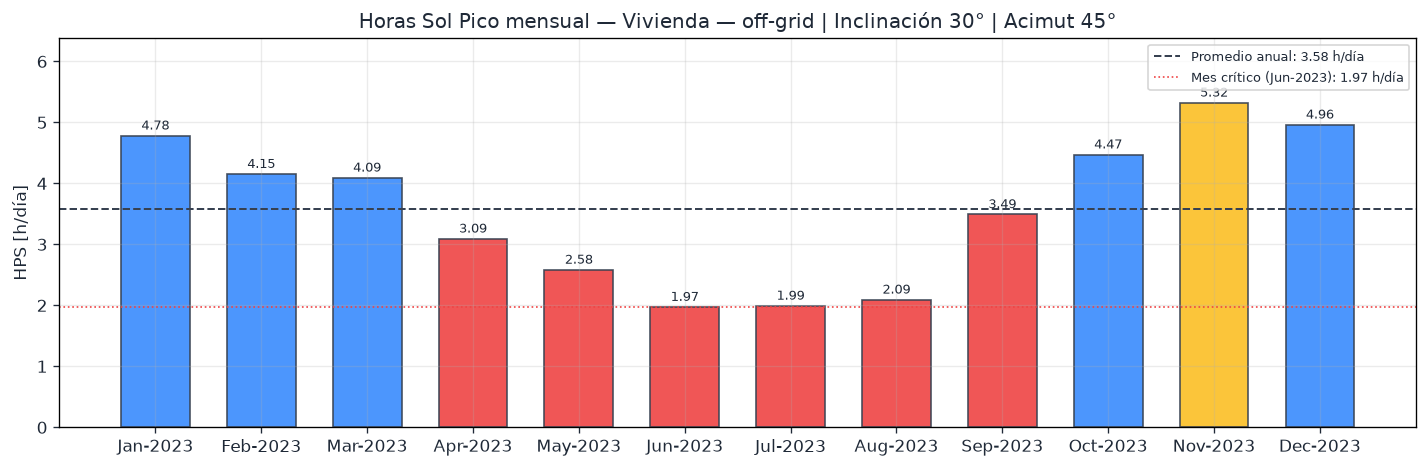

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
colores_hps = ['#fbbf24' if h >= 5.0 else '#388bfd' if h >= 3.5 else '#ef4444' for h in hps_df['HPS (h/día)']]
bars = ax.bar(hps_df['Mes'], hps_df['HPS (h/día)'], color=colores_hps, alpha=0.9, width=0.65, edgecolor='#374151')
for bar, val in zip(bars, hps_df['HPS (h/día)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, f'{val:.2f}', ha='center', va='bottom', fontsize=8)
ax.axhline(hps_promedio, color='#374151', linestyle='--', linewidth=1.2, label=f'Promedio anual: {hps_promedio:.2f} h/día')
ax.axhline(hps_minimo, color='#ef4444', linestyle=':', linewidth=1, label=f'Mes crítico ({mes_critico}): {hps_minimo:.2f} h/día')
ax.set_ylabel('HPS [h/día]')
ax.set_ylim(0, hps_df['HPS (h/día)'].max() * 1.2)
ax.set_title(f'Horas Sol Pico mensual — {NOMBRE_SITIO} | Inclinación {INCLINACION_GRADOS}° | Acimut {ACIMUT_GRADOS}°')
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.savefig('recurso_solar.png', bbox_inches='tight', dpi=120)
plt.show()

## 4. Dimensionamiento del generador fotovoltaico

Criterio del **mes más desfavorable** (off-grid: el sistema debe autoabastecerse incluso en el peor mes de recurso solar).

In [ ]:
# Pérdidas adicionales aguas abajo del generador FV (además del PR de irradiancia)
ETA_CONTROLADOR = CONTROLADOR['eta']
ETA_INVERSOR    = INVERSOR['eta']
ETA_CABLEADO    = 0.97

ETA_SISTEMA_TOTAL = PR * ETA_CONTROLADOR * ETA_INVERSOR * ETA_CABLEADO

Potencia_FV_necesaria = Ed / (hps_minimo * ETA_SISTEMA_TOTAL)  # Wp

n_paneles_necesarios = math.ceil(Potencia_FV_necesaria / PANEL['Wp'])

print("DIMENSIONAMIENTO DEL GENERADOR FV")
print("═" * 55)
print(f"  Consumo diario (Ed)          : {Ed:.0f} Wh/día")
print(f"  HSP mes crítico ({mes_critico})       : {hps_minimo:.2f} h/día")
print(f"  PR irradiancia                : {PR:.2f}")
print(f"  η controlador                 : {ETA_CONTROLADOR:.2f}")
print(f"  η inversor                    : {ETA_INVERSOR:.2f}")
print(f"  η cableado                    : {ETA_CABLEADO:.2f}")
print(f"  η sistema total                : {ETA_SISTEMA_TOTAL:.3f}")
print("─" * 55)
print(f"  Potencia FV necesaria         : {Potencia_FV_necesaria:.0f} Wp")
print(f"  Panel elegido                 : {PANEL['modelo']} ({PANEL['Wp']} Wp)")
print(f"  Paneles necesarios            : {n_paneles_necesarios}")
print(f"  Potencia FV instalada         : {n_paneles_necesarios*PANEL['Wp']:.0f} Wp")

DIMENSIONAMIENTO DEL GENERADOR FV
═══════════════════════════════════════════════════════
  Consumo diario (Ed)          : 2245 Wh/día
  HSP mes crítico (Jun-2023)       : 1.97 h/día
  PR irradiancia                : 0.78
  η controlador                 : 0.97
  η inversor                    : 0.93
  η cableado                    : 0.97
  η sistema total                : 0.683
───────────────────────────────────────────────────────
  Potencia FV necesaria         : 1670 Wp
  Panel elegido                 : Panel monocristalino 450W (450 Wp)
  Paneles necesarios            : 4
  Potencia FV instalada         : 1800 Wp


## 5. Configuración del array — Strings en serie y en paralelo

A diferencia de un sistema on-grid (limitado por la ventana MPPT del inversor de red), acá el
límite lo impone el **controlador de carga MPPT**: su tensión máxima de entrada FV y su
corriente máxima admisible.

$$N_{serie,max} = \left\lfloor \frac{V_{pv,max}}{V_{oc}(T_{min})} \right\rfloor$$

In [ ]:
def Voc_T(T):
    return PANEL['Voc_stc'] * (1 + PANEL['beta_oc']/100 * (T-25))

def Vmpp_T(T):
    return PANEL['Vmpp_stc'] * (1 + PANEL['beta_oc']/100 * (T-25))

Voc_frio  = Voc_T(T_CEL_MIN)
Vmpp_frio = Vmpp_T(T_CEL_MIN)

N_serie_max = math.floor(CONTROLADOR['V_pv_max'] / Voc_frio)
N_serie_min = math.ceil((V_SISTEMA * 1.15) / PANEL['Vmpp_stc'])  # margen sobre V_bat para asegurar carga

N_SERIE = min(N_serie_max, max(N_serie_min, N_serie_max))  # elegir dentro del rango válido
N_SERIE = N_serie_max  # criterio: maximizar aprovechamiento de la ventana del controlador

V_oc_string_frio = N_SERIE * Voc_frio

print("CÁLCULO DE PANELES EN SERIE (limitado por el controlador MPPT)")
print("═" * 60)
print(f"  Voc({T_CEL_MIN}°C) por panel   : {Voc_frio:.2f} V")
print(f"  N_serie máx (V_pv_max controlador) : floor({CONTROLADOR['V_pv_max']}/{Voc_frio:.2f}) = {N_serie_max}")
print(f"  N_serie mínimo sugerido (>V_bat)   : {N_serie_min}")
print(f"  N_SERIE elegido                    : {N_SERIE}")
print()
ok1 = V_oc_string_frio < CONTROLADOR['V_pv_max']
print(f"  Voc string a frío = {V_oc_string_frio:.1f} V < V_pv_max = {CONTROLADOR['V_pv_max']} V  "
      f"{'✓ OK' if ok1 else '✗ FALLA — reducir N_SERIE'}")

# ── Strings en paralelo, limitado por corriente del controlador ──────
N_paralelo_max = math.floor(CONTROLADOR['I_pv_max'] / PANEL['Isc_stc'])
N_PARALELO = max(1, min(N_paralelo_max, math.ceil(n_paneles_necesarios / N_SERIE)))

I_sc_campo = N_PARALELO * PANEL['Isc_stc']

print()
print("CÁLCULO DE STRINGS EN PARALELO")
print("═" * 60)
print(f"  N_paralelo máx (I_pv_max controlador) : floor({CONTROLADOR['I_pv_max']}/{PANEL['Isc_stc']}) = {N_paralelo_max}")
print(f"  N_PARALELO elegido                     : {N_PARALELO}")
ok2 = I_sc_campo <= CONTROLADOR['I_pv_max']
print(f"  Isc campo = {I_sc_campo:.1f} A ≤ I_pv_max = {CONTROLADOR['I_pv_max']} A  "
      f"{'✓ OK' if ok2 else '✗ FALLA — reducir N_PARALELO o sumar otro controlador'}")

n_total_paneles = N_SERIE * N_PARALELO
P_dc_total_w = n_total_paneles * PANEL['Wp']
print()
print(f"  Configuración final: {N_SERIE}S × {N_PARALELO}P = {n_total_paneles} paneles")
print(f"  Potencia DC total   : {P_dc_total_w:,} W ({P_dc_total_w/1000:.2f} kWp)")

if n_total_paneles < n_paneles_necesarios:
    print(f"  ⚠ La configuración cubre {n_total_paneles} de los {n_paneles_necesarios} paneles necesarios")
    print(f"    → considerar un segundo controlador MPPT/string, o un controlador de mayor corriente")

CÁLCULO DE PANELES EN SERIE (limitado por el controlador MPPT)
════════════════════════════════════════════════════════════
  Voc(-5.0°C) por panel   : 45.19 V
  N_serie máx (V_pv_max controlador) : floor(150/45.19) = 3
  N_serie mínimo sugerido (>V_bat)   : 2
  N_SERIE elegido                    : 3

  Voc string a frío = 135.6 V < V_pv_max = 150 V  ✓ OK

CÁLCULO DE STRINGS EN PARALELO
════════════════════════════════════════════════════════════
  N_paralelo máx (I_pv_max controlador) : floor(70/13.9) = 5
  N_PARALELO elegido                     : 2
  Isc campo = 27.8 A ≤ I_pv_max = 70 A  ✓ OK

  Configuración final: 3S × 2P = 6 paneles
  Potencia DC total   : 2,700 W (2.70 kWp)


## 6. Banco de baterías

In [ ]:
# Capacidad necesaria del banco
Wh_banco       = (Ed * DIAS_AUTONOMIA) / (DOD * ETA_BATERIA)
Ah_banco_a_Vsis = Wh_banco / V_SISTEMA

print("DIMENSIONAMIENTO DEL BANCO DE BATERÍAS")
print("═" * 60)
print(f"  Consumo diario (Ed)        : {Ed:.0f} Wh/día")
print(f"  Días de autonomía          : {DIAS_AUTONOMIA}")
print(f"  DoD                        : {DOD*100:.0f}%")
print(f"  η batería                  : {ETA_BATERIA*100:.0f}%")
print("─" * 60)
print(f"  Energía útil necesaria     : {Wh_banco/1000:.2f} kWh")
print(f"  Capacidad necesaria        : {Ah_banco_a_Vsis:.0f} Ah @ {V_SISTEMA} V")
print()

# Arreglo serie/paralelo de baterías individuales para alcanzar V_SISTEMA
n_serie_bat = math.ceil(V_SISTEMA / BATERIA['V_nom'])
V_banco_serie = n_serie_bat * BATERIA['V_nom']
n_paralelo_bat = math.ceil(Ah_banco_a_Vsis / BATERIA['Ah'])
n_total_baterias = n_serie_bat * n_paralelo_bat

print(f"  Batería individual         : {BATERIA['modelo']} ({BATERIA['V_nom']}V, {BATERIA['Ah']}Ah)")
print(f"  Baterías en serie           : {n_serie_bat}  →  {V_banco_serie} V")
print(f"  Strings en paralelo         : {n_paralelo_bat}  →  {n_paralelo_bat*BATERIA['Ah']} Ah")
print(f"  Total de baterías           : {n_total_baterias}")
print(f"  Capacidad instalada         : {n_paralelo_bat*BATERIA['Ah']} Ah @ {V_banco_serie} V "
      f"= {n_paralelo_bat*BATERIA['Ah']*V_banco_serie/1000:.2f} kWh")

ok_v = V_banco_serie == V_SISTEMA
print()
print(f"  Tensión del banco = {V_banco_serie} V {'✓ coincide' if ok_v else '⚠ verificar V_SISTEMA'} con V_SISTEMA = {V_SISTEMA} V")

DIMENSIONAMIENTO DEL BANCO DE BATERÍAS
════════════════════════════════════════════════════════════
  Consumo diario (Ed)        : 2245 Wh/día
  Días de autonomía          : 2
  DoD                        : 50%
  η batería                  : 88%
────────────────────────────────────────────────────────────
  Energía útil necesaria     : 10.20 kWh
  Capacidad necesaria        : 213 Ah @ 48 V

  Batería individual         : Batería GEL 12V 200Ah (12V, 200Ah)
  Baterías en serie           : 4  →  48 V
  Strings en paralelo         : 2  →  400 Ah
  Total de baterías           : 8
  Capacidad instalada         : 400 Ah @ 48 V = 19.20 kWh

  Tensión del banco = 48 V ✓ coincide con V_SISTEMA = 48 V


In [ ]:
# Corriente de carga del banco en el momento de mayor generación — verificación contra el controlador
P_pico_generacion = P_dc_total_w * PR
I_carga_pico = P_pico_generacion / V_SISTEMA

print("VERIFICACIÓN DE CORRIENTE DE CARGA AL BANCO")
print("═" * 55)
print(f"  Potencia pico de generación (aprox.) : {P_pico_generacion:.0f} W")
print(f"  Corriente de carga estimada           : {I_carga_pico:.1f} A")
ok3 = I_carga_pico <= CONTROLADOR['I_bat_max']
print(f"  I_carga ({I_carga_pico:.1f}A) ≤ I_bat_max controlador ({CONTROLADOR['I_bat_max']}A)  "
      f"{'✓ OK' if ok3 else '✗ FALLA — elegir controlador de mayor corriente o sumar otro'}")

VERIFICACIÓN DE CORRIENTE DE CARGA AL BANCO
═══════════════════════════════════════════════════════
  Potencia pico de generación (aprox.) : 2106 W
  Corriente de carga estimada           : 43.9 A
  I_carga (43.9A) ≤ I_bat_max controlador (70A)  ✓ OK


## 7. Selección del inversor off-grid

In [ ]:
FACTOR_ARRANQUE = INVERSOR['P_ac_surge_w'] / INVERSOR['P_ac_nom_w']

print(f"INVERSOR SELECCIONADO: {INVERSOR['modelo']}")
print("═" * 55)
print(f"  Potencia nominal continua  : {INVERSOR['P_ac_nom_w']:,} W")
print(f"  Potencia pico/surge        : {INVERSOR['P_ac_surge_w']:,} W  (x{FACTOR_ARRANQUE:.1f} nominal)")
print(f"  Tensión DC de entrada      : {INVERSOR['V_dc_nom']} V")
print(f"  Eficiencia                 : {INVERSOR['eta']*100:.1f}%")
print(f"  Salida AC                  : {INVERSOR['V_ac']} V / {INVERSOR['fases']}F")
print("═" * 55)
print()

ok_nom = INVERSOR['P_ac_nom_w'] >= Pico_simultaneo
print(f"  Potencia simultánea de cargas : {Pico_simultaneo:.0f} W")
print(f"  P_nominal inversor ({INVERSOR['P_ac_nom_w']}W) ≥ carga simultánea  "
      f"{'✓ OK' if ok_nom else '✗ FALLA — subir de inversor'}")

# Estimación de arranque de motor más exigente (bomba de agua, 3-6x su potencia nominal)
bomba = cargas[cargas['Artefacto'].str.contains('Bomba', case=False, na=False)]
if not bomba.empty:
    P_arranque_bomba = bomba['Potencia_W'].values[0] * 4  # factor típico de arranque
    ok_surge = INVERSOR['P_ac_surge_w'] >= P_arranque_bomba
    print(f"  Arranque estimado bomba (x4)  : {P_arranque_bomba:.0f} W")
    print(f"  P_surge inversor ({INVERSOR['P_ac_surge_w']}W) ≥ arranque bomba  "
          f"{'✓ OK' if ok_surge else '✗ FALLA — subir de inversor'}")

INVERSOR SELECCIONADO: Inversor/cargador off-grid senoidal puro
═══════════════════════════════════════════════════════
  Potencia nominal continua  : 3,000 W
  Potencia pico/surge        : 6,000 W  (x2.0 nominal)
  Tensión DC de entrada      : 48 V
  Eficiencia                 : 93.0%
  Salida AC                  : 220 V / 1F
═══════════════════════════════════════════════════════

  Potencia simultánea de cargas : 719 W
  P_nominal inversor (3000W) ≥ carga simultánea  ✓ OK
  Arranque estimado bomba (x4)  : 1600 W
  P_surge inversor (6000W) ≥ arranque bomba  ✓ OK


## 8. Verificación en condiciones extremas de temperatura

In [ ]:
Voc_calor = Voc_T(T_CEL_MAX)
Vmpp_calor = Vmpp_T(T_CEL_MAX)

print(f"  Parámetros del panel a distintas temperaturas:")
print(f"  {'Parámetro':<12} {'STC (25°C)':>12} {'Frío ('+str(T_CEL_MIN)+'°C)':>14} {'Calor ('+str(T_CEL_MAX)+'°C)':>14}")
print(f"  {'─'*54}")
print(f"  {'Voc [V]':<12} {PANEL['Voc_stc']:>12.2f} {Voc_frio:>14.2f} {Voc_calor:>14.2f}")
print(f"  {'Vmpp [V]':<12} {PANEL['Vmpp_stc']:>12.2f} {Vmpp_frio:>14.2f} {Vmpp_calor:>14.2f}")
print()
V_mpp_string_calor = N_SERIE * Vmpp_calor
ok4 = V_mpp_string_calor > V_SISTEMA * 1.1
print(f"  Vmpp string a calor = {V_mpp_string_calor:.1f} V > V_sistema x1.1 = {V_SISTEMA*1.1:.0f} V  "
      f"{'✓ OK — el string sigue cargando la batería en el día más caluroso' if ok4 else '✗ Riesgo de no cargar en días calurosos — subir N_SERIE'}")

  Parámetros del panel a distintas temperaturas:
  Parámetro      STC (25°C)  Frío (-5.0°C) Calor (71.0°C)
  ──────────────────────────────────────────────────────
  Voc [V]             41.80          45.19          36.61
  Vmpp [V]            34.90          37.73          30.57

  Vmpp string a calor = 91.7 V > V_sistema x1.1 = 53 V  ✓ OK — el string sigue cargando la batería en el día más caluroso


## 9. Generación mensual vs. consumo — balance energético

In [ ]:
gen_df = hps_df.copy()
gen_df['Generación (kWh)'] = (P_dc_total_w/1000 * gen_df['HPS (h/día)'] * ETA_SISTEMA_TOTAL * 30).round(1)
gen_df['Consumo (kWh)']    = round(Ed/1000 * 30, 1)
gen_df['Balance (kWh)']    = (gen_df['Generación (kWh)'] - gen_df['Consumo (kWh)']).round(1)
gen_df['Cobertura (%)']    = (gen_df['Generación (kWh)'] / gen_df['Consumo (kWh)'] * 100).round(1)

print("BALANCE ENERGÉTICO MENSUAL")
print(f"Sistema: {N_SERIE}S×{N_PARALELO}P — {P_dc_total_w/1000:.2f} kWp DC")
print()
print(f"  {'Mes':<10} {'HSP h/día':>10} {'Gen. kWh':>10} {'Consumo kWh':>13} {'Balance':>10} {'Cobertura':>10}")
print(f"  {'─'*68}")
for _, row in gen_df.iterrows():
    print(f"  {row['Mes']:<10} {row['HPS (h/día)']:>10.2f} {row['Generación (kWh)']:>10.1f} "
          f"{row['Consumo (kWh)']:>13.1f} {row['Balance (kWh)']:>10.1f} {row['Cobertura (%)']:>9.1f}%")

meses_deficit = gen_df[gen_df['Balance (kWh)'] < 0]
print()
if len(meses_deficit) > 0:
    print(f"  ⚠ Meses con déficit energético: {', '.join(meses_deficit['Mes'].tolist())}")
    print(f"    (el banco de baterías debe compensar la diferencia, dimensionado para {DIAS_AUTONOMIA} días sin sol)")
else:
    print(f"  ✓ Generación cubre el consumo los 12 meses del año")

BALANCE ENERGÉTICO MENSUAL
Sistema: 3S×2P — 2.70 kWp DC

  Mes         HSP h/día   Gen. kWh   Consumo kWh    Balance  Cobertura
  ────────────────────────────────────────────────────────────────────
  Jan-2023         4.78      264.3          67.4      196.9     392.1%
  Feb-2023         4.15      229.4          67.4      162.0     340.4%
  Mar-2023         4.09      226.1          67.4      158.7     335.5%
  Apr-2023         3.09      170.8          67.4      103.4     253.4%
  May-2023         2.58      142.6          67.4       75.2     211.6%
  Jun-2023         1.97      108.9          67.4       41.5     161.6%
  Jul-2023         1.99      110.0          67.4       42.6     163.2%
  Aug-2023         2.09      115.5          67.4       48.1     171.4%
  Sep-2023         3.49      192.9          67.4      125.5     286.2%
  Oct-2023         4.47      247.1          67.4      179.7     366.6%
  Nov-2023         5.32      294.1          67.4      226.7     436.4%
  Dec-2023         4

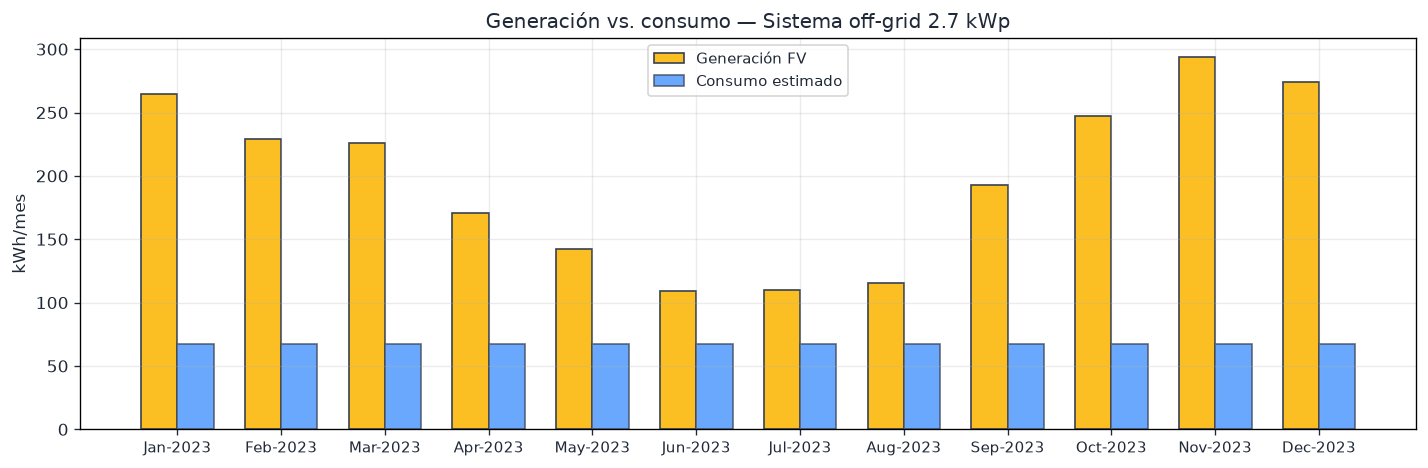

In [ ]:
fig, ax = plt.subplots(figsize=(12,4))
x = np.arange(len(gen_df))
w = 0.35
ax.bar(x - w/2, gen_df['Generación (kWh)'], w, color='#fbbf24', label='Generación FV', edgecolor='#374151')
ax.bar(x + w/2, gen_df['Consumo (kWh)'], w, color='#388bfd', alpha=0.75, label='Consumo estimado', edgecolor='#374151')
ax.set_xticks(x); ax.set_xticklabels(gen_df['Mes'], fontsize=9)
ax.set_ylabel('kWh/mes')
ax.set_title(f'Generación vs. consumo — Sistema off-grid {P_dc_total_w/1000:.1f} kWp')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('balance_energetico.png', bbox_inches='tight', dpi=120)
plt.show()

## 10. Resumen ejecutivo del diseño

In [ ]:
resumen_ejecutivo_md = f"""
### 📊 Resumen Ejecutivo — Sistema FV Off-Grid
**{NOMBRE_SITIO}**

| 📍 Sitio | Detalle |
| :--- | :--- |
| **Coordenadas** | {LATITUD}°, {LONGITUD}° |
| **Inclinación / Acimut** | {INCLINACION_GRADOS}° / {ACIMUT_GRADOS}° |

<br>

| ⚙️ Generador FV | Especificaciones |
| :--- | :--- |
| **Panel** | {PANEL['modelo']} |
| **Configuración** | {N_SERIE}S × {N_PARALELO}P = {n_total_paneles} paneles |
| **Potencia DC instalada** | {P_dc_total_w/1000:.2f} kWp |
| **Controlador de carga** | {CONTROLADOR['modelo']} (MPPT) |

<br>

| 🔋 Banco de Baterías | Especificaciones |
| :--- | :--- |
| **Tecnología** | Plomo-ácido GEL/AGM |
| **Tensión de sistema** | {V_SISTEMA} V |
| **Capacidad instalada** | {n_paralelo_bat*BATERIA['Ah']} Ah ({n_paralelo_bat*BATERIA['Ah']*V_banco_serie/1000:.2f} kWh) |
| **Configuración** | {n_serie_bat} serie × {n_paralelo_bat} paralelo = {n_total_baterias} baterías |
| **Autonomía de diseño** | {DIAS_AUTONOMIA} días |

<br>

| 🔌 Inversor | Especificaciones |
| :--- | :--- |
| **Modelo** | {INVERSOR['modelo']} |
| **Potencia nominal / surge** | {INVERSOR['P_ac_nom_w']}W / {INVERSOR['P_ac_surge_w']}W |

<br>

| ⚡ Consumo y Generación | Valores |
| :--- | :--- |
| **Consumo diario (Ed)** | {Ed:.0f} Wh/día |
| **HSP mes crítico ({mes_critico})** | {hps_minimo:.2f} h/día |
| **Cobertura anual promedio** | {gen_df['Cobertura (%)'].mean():.0f}% |
"""
display(Markdown(resumen_ejecutivo_md))


### 📊 Resumen Ejecutivo — Sistema FV Off-Grid
**Vivienda — off-grid**

| 📍 Sitio | Detalle |
| :--- | :--- |
| **Coordenadas** | -34.6°, -58.4° |
| **Inclinación / Acimut** | 30° / 45° |

<br>

| ⚙️ Generador FV | Especificaciones |
| :--- | :--- |
| **Panel** | Panel monocristalino 450W |
| **Configuración** | 3S × 2P = 6 paneles |
| **Potencia DC instalada** | 2.70 kWp |
| **Controlador de carga** | MPPT 150/70 (MPPT) |

<br>

| 🔋 Banco de Baterías | Especificaciones |
| :--- | :--- |
| **Tecnología** | Plomo-ácido GEL/AGM |
| **Tensión de sistema** | 48 V |
| **Capacidad instalada** | 400 Ah (19.20 kWh) |
| **Configuración** | 4 serie × 2 paralelo = 8 baterías |
| **Autonomía de diseño** | 2 días |

<br>

| 🔌 Inversor | Especificaciones |
| :--- | :--- |
| **Modelo** | Inversor/cargador off-grid senoidal puro |
| **Potencia nominal / surge** | 3000W / 6000W |

<br>

| ⚡ Consumo y Generación | Valores |
| :--- | :--- |
| **Consumo diario (Ed)** | 2245 Wh/día |
| **HSP mes crítico (Jun-2023)** | 1.97 h/día |
| **Cobertura anual promedio** | 294% |
